<a href="https://colab.research.google.com/github/rumeysaBakar/NerfWithAi/blob/main/NerfWithAi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch torchvision
!pip install tinycudann
!pip install nerfacc
!pip install matplotlib imageio

ERROR: Could not find a version that satisfies the requirement tinycudann (from versions: none)
ERROR: No matching distribution found for tinycudann


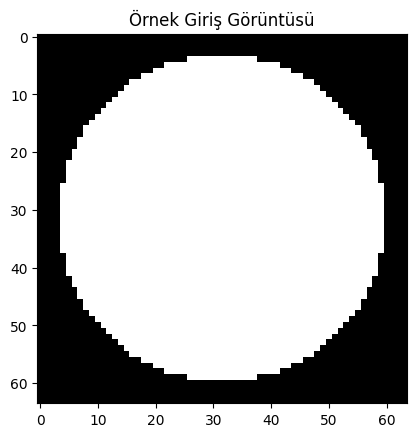

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def create_sphere_dataset(num_images=20, image_size=64):
    poses = []
    images = []

    for i in range(num_images):

        theta = 2 * np.pi * i / num_images
        pose = torch.eye(4)
        pose[0, 3] = 2 * np.sin(theta)
        pose[1, 3] = 0.5
        pose[2, 3] = 2 * np.cos(theta)
        poses.append(pose)

        x, y = np.meshgrid(np.linspace(-1, 1, image_size),
                          np.linspace(-1, 1, image_size))
        img = (x**2 + y**2 < 0.8).astype(np.float32)
        images.append(img)

    return torch.stack(poses), torch.tensor(np.stack(images))

poses, images = create_sphere_dataset()

plt.imshow(images[0], cmap='gray')
plt.title("Örnek Giriş Görüntüsü")
plt.show()

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class TinyNeRF(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(3 + 3*2*4, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 4)

    def forward(self, x):

        encoded = [x]
        for freq in [1, 2, 4, 8]:
            encoded.append(torch.sin(freq * x))
            encoded.append(torch.cos(freq * x))
        x = torch.cat(encoded, dim=-1)

        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)

        rgb = torch.sigmoid(x[..., :3])
        density = F.softplus(x[..., 3:])

        return torch.cat([rgb, density], dim=-1)

model = TinyNeRF().cuda()
print(model)

TinyNeRF(
  (layer1): Linear(in_features=27, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=4, bias=True)
)


In [5]:
def render_rays(model, rays_o, rays_d, near=0.5, far=2.5, num_samples=32):
    t_vals = torch.linspace(near, far, num_samples).cuda()
    points = rays_o[..., None, :] + rays_d[..., None, :] * t_vals[..., None]

    flattened_points = points.reshape(-1, 3)
    out = model(flattened_points)
    rgb = out[..., :3].reshape(*points.shape[:-1], 3)
    density = out[..., 3].reshape(*points.shape[:-1])

    delta = t_vals[..., 1:] - t_vals[..., :-1]
    alpha = 1 - torch.exp(-density[..., :-1] * delta)
    weights = alpha * torch.cumprod(1 - alpha + 1e-10, dim=-1)

    rgb_map = torch.sum(weights[..., None] * rgb[..., :-1, :], dim=-2)

    return rgb_map

rays_o = torch.tensor([[0, 0, -1]], dtype=torch.float32).cuda()
rays_d = torch.tensor([[0, 0, 1]], dtype=torch.float32).cuda()

test_render = render_rays(model, rays_o, rays_d)
print("Test render çıktısı:", test_render)

Test render çıktısı: tensor([[0.3131, 0.3239, 0.3367]], device='cuda:0', grad_fn=<SumBackward1>)


/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Epoch 0, Loss: 0.3276


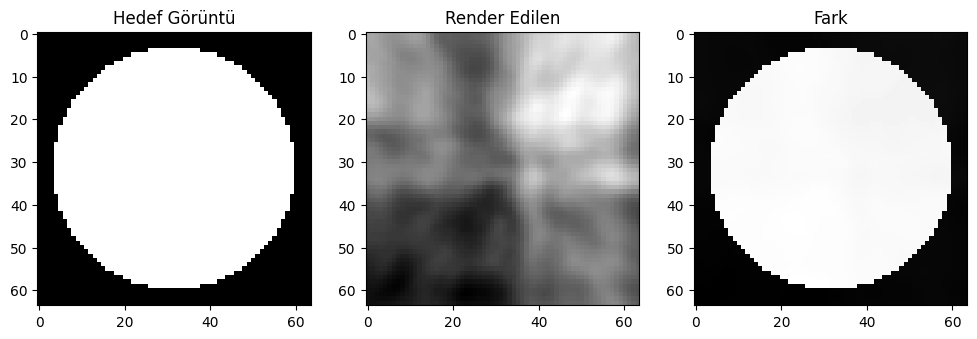

Epoch 100, Loss: 0.1553


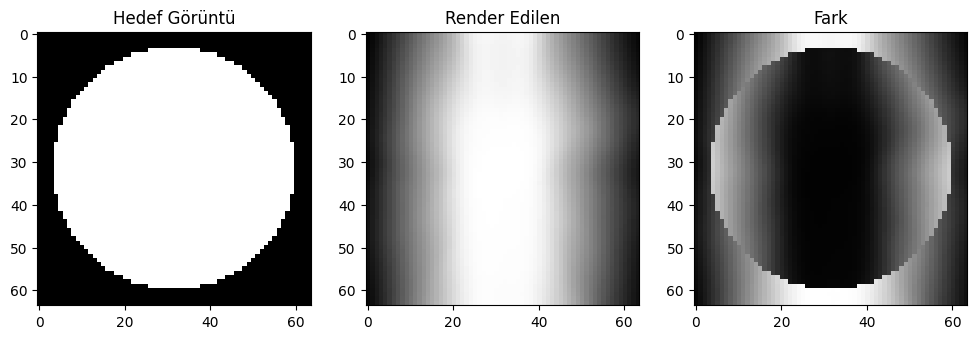

Epoch 200, Loss: 0.1532


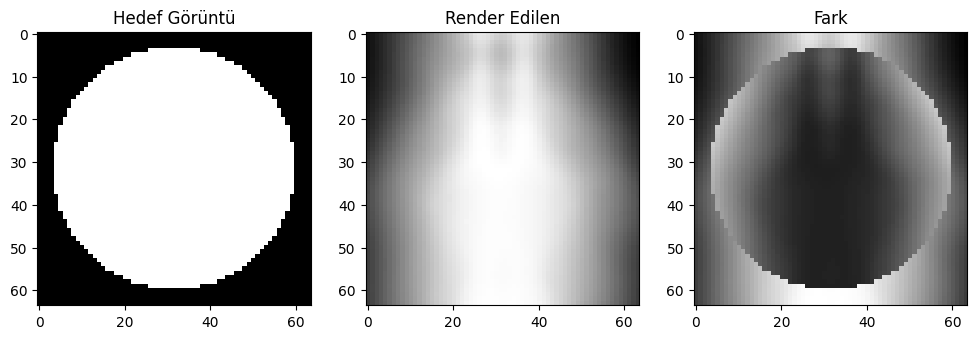

Epoch 300, Loss: 0.1224


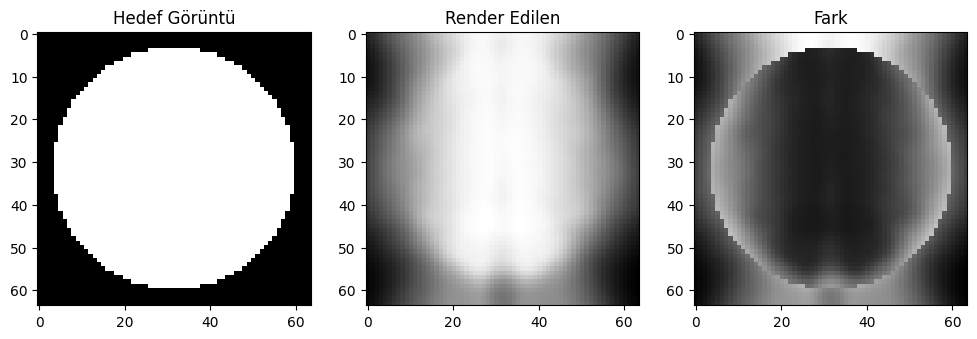

Epoch 400, Loss: 0.1260


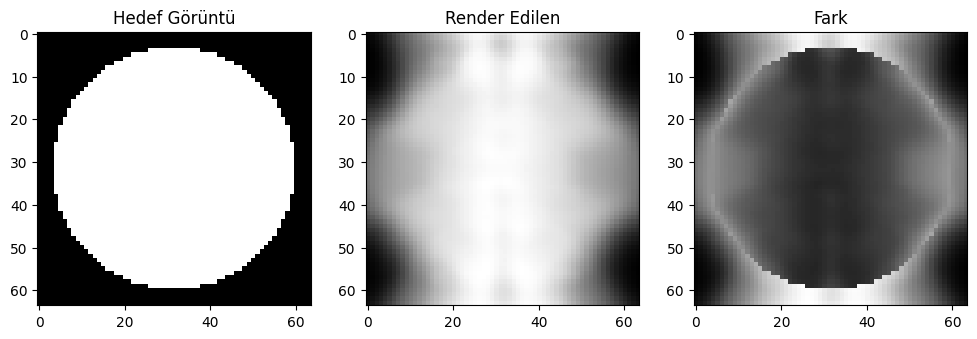

Epoch 500, Loss: 0.1534


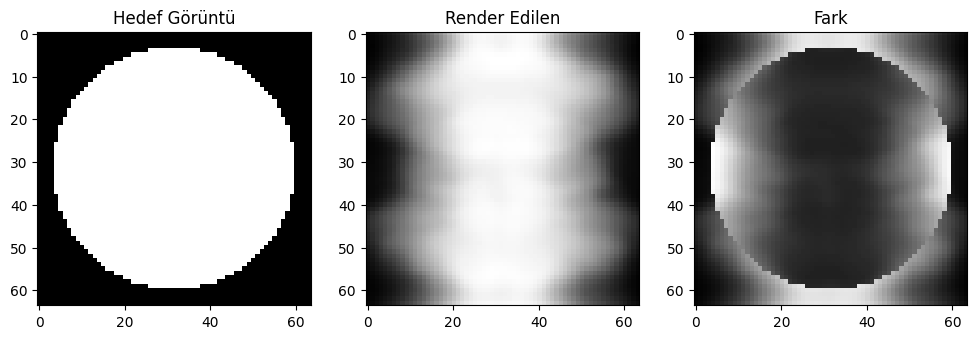

Epoch 600, Loss: 0.1438


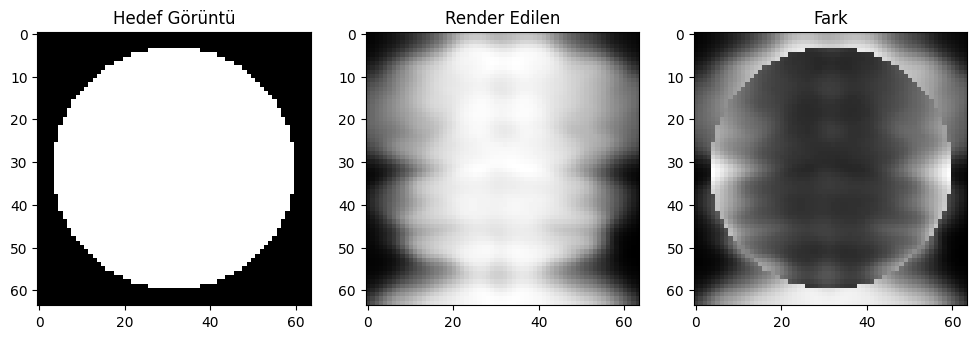

Epoch 700, Loss: 0.1148


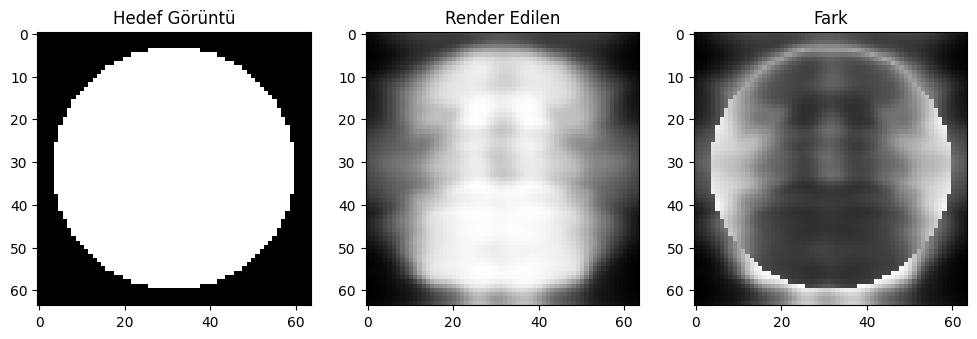

Epoch 800, Loss: 0.1001


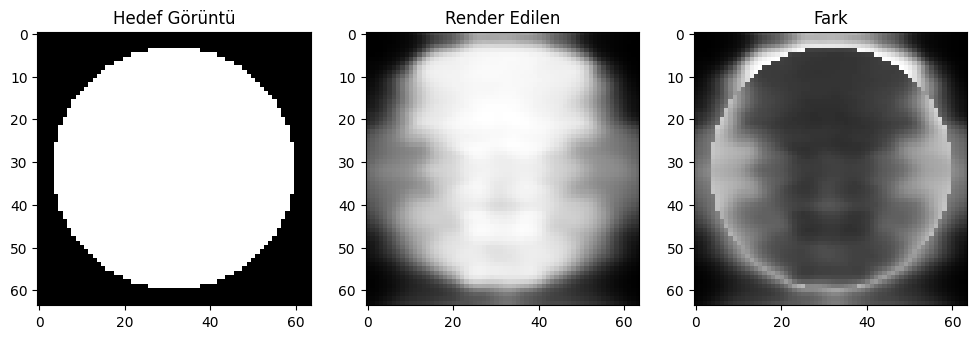

Epoch 900, Loss: 0.1188


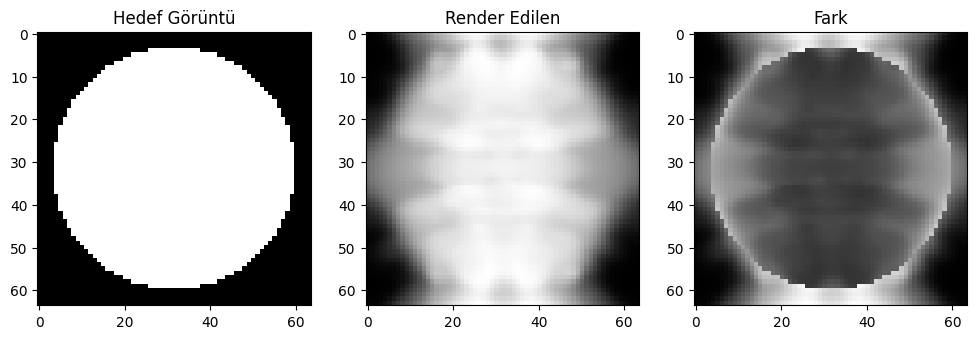

Epoch 1000, Loss: 0.1020


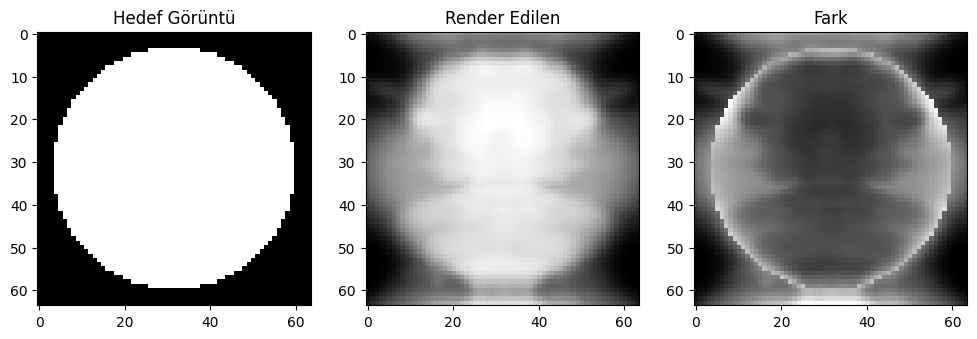

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(1001):
    optimizer.zero_grad()

    idx = torch.randint(0, len(images), (1,))
    target_img = images[idx].cuda()
    pose = poses[idx].cuda()

    H, W = target_img.shape[-2], target_img.shape[-1]
    i, j = torch.meshgrid(torch.linspace(-1, 1, W), torch.linspace(-1, 1, H))
    dirs = torch.stack([i, -j, -torch.ones_like(i)], -1).cuda()

    rays_d = torch.sum(dirs[..., None, :] * pose[0, :3, :3], -1)
    rays_o = pose[0, :3, 3].expand(rays_d.shape)

    rgb_map = render_rays(model, rays_o, rays_d)

    loss = loss_fn(rgb_map[..., 0], target_img[0])
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(target_img[0].cpu(), cmap='gray')
        plt.title("Hedef Görüntü")

        plt.subplot(1, 3, 2)
        plt.imshow(rgb_map[..., 0].detach().cpu(), cmap='gray')
        plt.title("Render Edilen")

        plt.subplot(1, 3, 3)
        plt.imshow((target_img[0] - rgb_map[..., 0].detach()).cpu().abs(), cmap='gray')
        plt.title("Fark")
        plt.show()

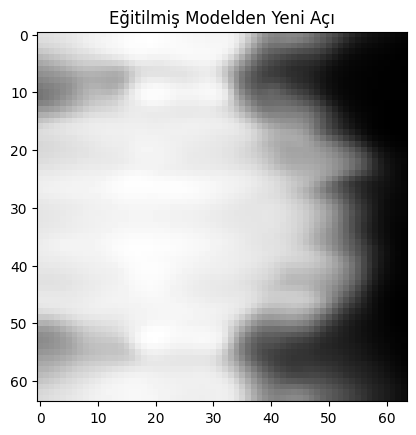

In [8]:
with torch.no_grad():
    new_pose = torch.eye(4).cuda()
    new_pose[2, 3] = -2.5

    H, W = 64, 64
    i, j = torch.meshgrid(torch.linspace(-1, 1, W), torch.linspace(-1, 1, H))
    dirs = torch.stack([i, -j, -torch.ones_like(i)], -1).cuda()
    rays_d = torch.sum(dirs[..., None, :] * new_pose[:3, :3], -1)
    rays_o = new_pose[:3, 3].expand(rays_d.shape)

    novel_view = render_rays(model, rays_o, rays_d)

plt.imshow(novel_view[..., 0].cpu(), cmap='gray')
plt.title("Eğitilmiş Modelden Yeni Açı")
plt.show()